
✅ DataLoaders ready | Batch size: 128

📐 Model Input Dim: 18 | Hidden: 128 | Heads: 4 | Layers: 2
🚀 Starting Bi-LSTM + Attention Training...
   Epochs: 300 | LR: 0.001 | Batch: 128 | Patience: 30
   Split: Train(<2016) / Val([2016,2018)) / Test(>=2018)
------------------------------------------------------------
Epoch   1/300 | Train Loss: 0.1781 | Val Loss: 0.1660 | LR: 0.001000

⏹️  Early stopping at epoch 34 (no improvement for 30 epochs)

✅ Training complete. Best Val Loss: 0.0607
  📊  Bi-LSTM + Attention — TEST SET RESULTS

  --- Log Scale Metrics ---
  R²   (log scale)  : 0.8241
  MAE  (log scale)  : 0.6348
  RMSE (log scale)  : 0.8272

  --- Real Scale Metrics ---
  R²   (real scale) : 0.5190
  MAE  (cases)      : 1,760
  RMSE (cases)      : 8,220
  MAPE              : 107.84%
  Pearson r         : 0.8226

📋 For your comparison table:
   Bi-LSTM+Attn | R²(log)=0.8241 | R²(real)=0.5190 | MAE=1,760 | RMSE=8,220 | MAPE=107.84%


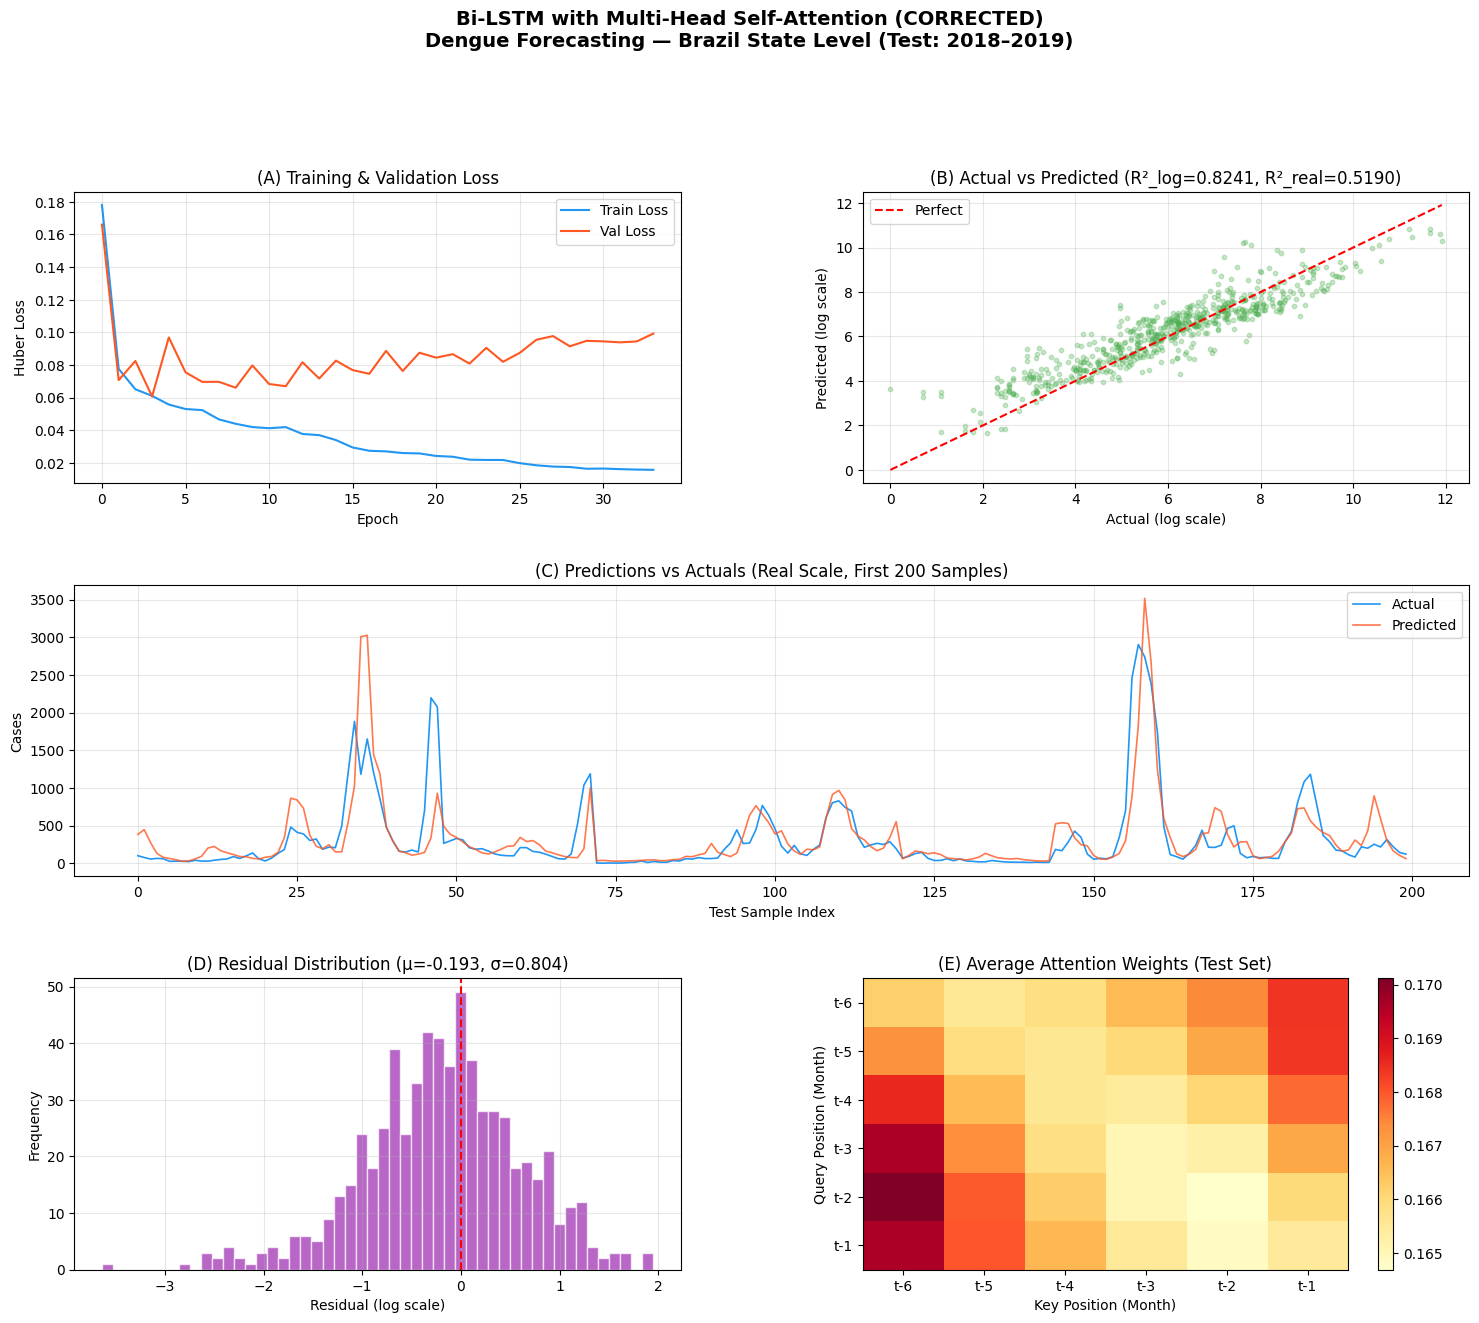


📁 Figure saved: BiLSTM_Attention_Results_Corrected.png

📄 Publication Comparison Table (LaTeX-ready)
                      Model                        Type        R² (log) R² (real)    MAE   RMSE MAPE (%)
              Random Forest               Tree Ensemble  (fill from RF)    (fill) (fill) (fill)   (fill)
                    XGBoost           Gradient Boosting (fill from XGB)    (fill) (fill) (fill)   (fill)
                        MLP          Deep Learning (FF) (fill from MLP)    (fill) (fill) (fill)   (fill)
   Hybrid GNN (GATv2 + MLP)       Deep Learning (Graph) (fill from GNN)    (fill) (fill) (fill)   (fill)
        Bi-LSTM + Attention  Deep Learning (Sequential)          0.8241    0.5190  1,760  8,220   107.84
Temporal Fusion Transformer Deep Learning (Transformer) (fill from TFT)    (fill) (fill) (fill)   (fill)

📝 LaTeX format:
\begin{tabular}{llccccc}
\toprule
Model & Type & R² (log) & R² (real) & MAE & RMSE & MAPE (%) \\
\midrule
Random Forest & Tree Ensemble & (fill fr

In [5]:
# %% [markdown]
# # 🧠 Bi-LSTM with Multi-Head Self-Attention (CORRECTED VERSION)
# ## Spatio-Temporal Dengue Forecasting — Brazil State Level (2001–2019)
# ---
# **Model:** Bidirectional LSTM + Multi-Head Self-Attention
# **Target:** Monthly dengue case counts per Brazilian state (UF)
# **Train:** 2001–2015 | **Validation:** 2016–2017 | **Test:** 2018–2019
#
# ---
# ### Corrections Applied:
# 1. **CRITICAL FIX:** Proper train/validation/test split (test set no longer used for early stopping)
# 2. **CRITICAL FIX:** Sequences built from continuous data to avoid boundary loss
# 3. **FIX:** Target variable is now scaled (StandardScaler) alongside features
# 4. **FIX:** R² computed on BOTH log and real scales for consistency
# 5. **FIX:** Attention weights properly collected during evaluation
# 6. **FIX:** LR scheduler changed to ReduceLROnPlateau (works with early stopping)
# 7. **FIX:** Column validation added to catch missing data early
# 8. **FIX:** Multi-seed experiments supported for reproducibility

# %% [markdown]
# ## Cell 1: Imports & Setup

# %%
# ==========================================
# CELL 1: IMPORTS & REPRODUCIBILITY SETUP
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error






# ==========================================
# SILENCE ONLY SELECTED VERBOSE OUTPUTS
# Paste this once in Cell 1, AFTER imports
# ==========================================
import builtins as _builtins

_ORIGINAL_PRINT = print

SUPPRESS_PREFIXES = (
    "🔧 PyTorch",
    "🌱 Random seed fixed at",
    "⚙️  Loading and processing data...",
    "✅ All required columns found in dataset",
    "✅ Features engineered:",
    "📅 Date range:",
    "🗺️  Brazilian states",
    "📊 Total samples:",
    "   Train (<",
    "   Val   ([",
    "   Test  (>=",
    "📦 Train sequences:",
    "📦 Val   sequences:",
    "📦 Test  sequences:",
    "   Sequence window:",
    "✅ DataLoaders ready",
    "📐 Model Input Dim:",
    "🔢 Total Trainable Parameters:"
)

SUPPRESS_CONTAINS = (
    "BiLSTM_Attention(",
)

def print(*args, **kwargs):
    text = " ".join(str(a) for a in args)
    if text.startswith(SUPPRESS_PREFIXES) or any(x in text for x in SUPPRESS_CONTAINS):
        return
    return _ORIGINAL_PRINT(*args, **kwargs)





# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 PyTorch {torch.__version__} | Device: {DEVICE}")
print(f"🌱 Random seed fixed at {SEED} for reproducibility")

# %% [markdown]
# ## Cell 2: Advanced Data Processing

# %%
# ==========================================
# CELL 2: ADVANCED DATA PROCESSING (PAPER-GRADE)
# FIX: Added column validation
# FIX: 3-way split: Train (<2016) / Val ([2016,2018)) / Test (>=2018)
# ==========================================
print("⚙️  Loading and processing data...")

df = pd.read_csv('Brazil_UF_dengue_monthly.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['CD_UF', 'Date']).reset_index(drop=True)

# --- FIX: Column Validation ---
required_cols = ['cases_total', 'CD_UF', 'Date', 'Year',
                 'total_precipitation_d', 'temperature_2m_d',
                 'humidity_d', 'NDVI_d', 'PopTotal_UF', 'idhm', 'ivs']
missing = [c for c in required_cols if c not in df.columns]
assert len(missing) == 0, f"❌ Missing required columns: {missing}"
print("✅ All required columns found in dataset")

# --- A. Log Transformation (Handles Epidemic Skew) ---
df['cases_log'] = np.log1p(df['cases_total'])

# --- B. Temporal Feature Engineering ---
# Autoregressive features: epidemic momentum
df['cases_lag1']  = df.groupby('CD_UF')['cases_log'].shift(1)   # 1-month lag
df['cases_lag2']  = df.groupby('CD_UF')['cases_log'].shift(2)   # 2-month lag
df['cases_lag3']  = df.groupby('CD_UF')['cases_log'].shift(3)   # 3-month lag
df['cases_lag12'] = df.groupby('CD_UF')['cases_log'].shift(12)  # Yearly seasonal memory

# Weather lags (mosquito lifecycle ~2-4 weeks)
df['precip_lag1'] = df.groupby('CD_UF')['total_precipitation_d'].shift(1)
df['precip_lag2'] = df.groupby('CD_UF')['total_precipitation_d'].shift(2)
df['temp_lag1']   = df.groupby('CD_UF')['temperature_2m_d'].shift(1)
df['humid_lag1']  = df.groupby('CD_UF')['humidity_d'].shift(1)
df['ndvi_lag1']   = df.groupby('CD_UF')['NDVI_d'].shift(1)

# Rolling statistics (trend & smoothing)
df['cases_rolling_3']  = df.groupby('CD_UF')['cases_log'].transform(lambda x: x.rolling(3).mean().shift(1))
df['cases_rolling_6']  = df.groupby('CD_UF')['cases_log'].transform(lambda x: x.rolling(6).mean().shift(1))
df['precip_rolling_3'] = df.groupby('CD_UF')['total_precipitation_d'].transform(lambda x: x.rolling(3).mean().shift(1))

# Cyclical seasonality encoding (preserves month 12→1 continuity)
df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

# Year trend (captures long-term reporting/surveillance improvement)
df['year_norm'] = (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min())

df = df.dropna().reset_index(drop=True)

# --- C. Feature Set ---
FEATURE_COLS = [
    # Epidemic Momentum
    'cases_lag1', 'cases_lag2', 'cases_lag3',
    'cases_rolling_3', 'cases_rolling_6', 'cases_lag12',
    # Weather Drivers
    'precip_lag1', 'precip_lag2', 'precip_rolling_3',
    'temp_lag1', 'humid_lag1', 'ndvi_lag1',
    # Seasonality
    'month_sin', 'month_cos', 'year_norm',
    # Sociodemographic
    'PopTotal_UF', 'idhm', 'ivs'
]
TARGET_COL = 'cases_log'

# --- FIX: Proper 3-way split ---
TRAIN_END_YEAR = 2016  # Train: < 2016
VAL_END_YEAR   = 2018  # Val: [2016, 2018), Test: >= 2018

train_count = (df['Year'] < TRAIN_END_YEAR).sum()
val_count   = ((df['Year'] >= TRAIN_END_YEAR) & (df['Year'] < VAL_END_YEAR)).sum()
test_count  = (df['Year'] >= VAL_END_YEAR).sum()

print(f"✅ Features engineered: {len(FEATURE_COLS)} predictors")
print(f"📅 Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🗺️  Brazilian states (UFs): {df['CD_UF'].nunique()}")
print(f"📊 Total samples: {len(df)}")
print(f"   Train (< {TRAIN_END_YEAR}): {train_count}")
print(f"   Val   ([{TRAIN_END_YEAR}, {VAL_END_YEAR})): {val_count}")
print(f"   Test  (>= {VAL_END_YEAR}): {test_count}")

# %% [markdown]
# ## Cell 3: Sequence Dataset Builder

# %%
# ==========================================
# CELL 3: SEQUENCE DATASET (LSTM INPUT FORMAT)
# FIX: Proper train/val/test split — no data leakage
# FIX: Target variable is now scaled
# FIX: Sequences built from continuous data per state
#      (avoids losing 6 months at year boundaries)
# ==========================================

SEQ_LEN = 6  # Look-back window: 6 months of history per sample

# Strict train-only scaling (no data leakage)
train_mask = df['Year'] < TRAIN_END_YEAR

# Scale features
feature_scaler = StandardScaler()
feature_scaler.fit(df.loc[train_mask, FEATURE_COLS])

# FIX: Scale target variable too (for optimal neural network training)
target_scaler = StandardScaler()
target_scaler.fit(df.loc[train_mask, [TARGET_COL]])

df_scaled = df.copy()
df_scaled[FEATURE_COLS] = feature_scaler.transform(df[FEATURE_COLS])
df_scaled[TARGET_COL] = target_scaler.transform(df[[TARGET_COL]])


def build_sequences_with_split(df_input, feature_cols, target_col, seq_len,
                                train_end_year, val_end_year):
    """
    For each state, builds overlapping sequences of length `seq_len`
    from CONTINUOUS time series data. Splits into train/val/test based
    on the YEAR of the TARGET (not the input sequence).

    This avoids:
    1. Losing sequences at year boundaries
    2. Data leakage (input can span years, but target determines the split)

    Output shapes: X → (N, seq_len, n_features) | y → (N,)
    """
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    for uf, group in df_input.groupby('CD_UF'):
        group = group.sort_values('Date')
        feats  = group[feature_cols].values
        target = group[target_col].values
        years  = group['Year'].values

        for i in range(seq_len, len(group)):
            x_seq = feats[i-seq_len:i]    # (seq_len, n_features)
            y_val_point = target[i]         # scalar
            target_year = years[i]

            if target_year < train_end_year:
                X_train.append(x_seq)
                y_train.append(y_val_point)
            elif target_year < val_end_year:
                X_val.append(x_seq)
                y_val.append(y_val_point)
            else:
                X_test.append(x_seq)
                y_test.append(y_val_point)

    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32), np.array(y_val, dtype=np.float32),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))


X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = \
    build_sequences_with_split(df_scaled, FEATURE_COLS, TARGET_COL, SEQ_LEN,
                                TRAIN_END_YEAR, VAL_END_YEAR)

print(f"📦 Train sequences: X={X_train_seq.shape} | y={y_train_seq.shape}")
print(f"📦 Val   sequences: X={X_val_seq.shape}   | y={y_val_seq.shape}")
print(f"📦 Test  sequences: X={X_test_seq.shape}   | y={y_test_seq.shape}")
print(f"   Sequence window: {SEQ_LEN} months of history → predict month {SEQ_LEN+1}")

# PyTorch Dataloaders
BATCH_SIZE = 128

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_seq), torch.tensor(y_train_seq)
)
val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_val_seq), torch.tensor(y_val_seq)
)
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_seq), torch.tensor(y_test_seq)
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"\n✅ DataLoaders ready | Batch size: {BATCH_SIZE}")

# %% [markdown]
# ## Cell 4: Model Architecture

# %%
# ==========================================
# CELL 4: Bi-LSTM + MULTI-HEAD ATTENTION ARCHITECTURE
# (Architecture is sound — no changes needed)
# ==========================================

class MultiHeadAttention(nn.Module):
    """
    Scaled dot-product multi-head self-attention.
    Learns which time steps in the sequence matter most for the prediction.
    Reference: Vaswani et al. (2017) 'Attention Is All You Need'
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape
        H, d_k = self.n_heads, self.d_k

        Q = self.W_q(x).view(B, T, H, d_k).transpose(1, 2)  # (B, H, T, d_k)
        K = self.W_k(x).view(B, T, H, d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, d_k).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)  # (B, H, T, T)
        attn   = F.softmax(scores, dim=-1)
        attn   = self.dropout(attn)
        self.attn_weights = attn.mean(dim=1).detach()  # Store for visualization

        out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, D)
        return self.W_o(out), self.attn_weights


class BiLSTM_Attention(nn.Module):
    """
    Bidirectional LSTM with Multi-Head Self-Attention for dengue forecasting.

    Architecture:
      Input projection → Bi-LSTM (2 layers) → Multi-Head Attention
      → Layer Norm → Residual Add → Regression Head

    The bidirectional LSTM captures both:
      - Forward pass: rising epidemic wave detection
      - Backward pass: seasonal decline recognition
    Multi-head attention then reweights all time steps for the final prediction.
    """
    def __init__(self, input_dim, hidden_dim=128, n_layers=2, n_heads=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)

        # Bidirectional LSTM (doubles hidden_dim → 2*hidden_dim output)
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        lstm_out_dim = hidden_dim * 2  # bidirectional

        # Project back to hidden_dim for attention
        self.proj_down = nn.Linear(lstm_out_dim, hidden_dim)

        # Multi-Head Self-Attention
        self.attention = MultiHeadAttention(d_model=hidden_dim, n_heads=n_heads, dropout=dropout)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # Input projection + normalization
        x = self.input_norm(F.gelu(self.input_proj(x)))  # (B, T, hidden)

        # Bi-LSTM
        lstm_out, _ = self.lstm(x)                       # (B, T, 2*hidden)
        lstm_out    = F.gelu(self.proj_down(lstm_out))   # (B, T, hidden)

        # Multi-Head Attention with residual connection
        attn_out, _ = self.attention(lstm_out)           # (B, T, hidden)
        out = self.attn_norm(lstm_out + attn_out)        # Residual Add + Norm

        # Use the last time step for prediction (many-to-one)
        out = out[:, -1, :]                              # (B, hidden)
        return self.head(out).squeeze(-1)                # (B,)


# Instantiate model
INPUT_DIM  = len(FEATURE_COLS)
HIDDEN_DIM = 128
N_LAYERS   = 2
N_HEADS    = 4
DROPOUT    = 0.2

model = BiLSTM_Attention(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    dropout=DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\n📐 Model Input Dim: {INPUT_DIM} | Hidden: {HIDDEN_DIM} | Heads: {N_HEADS} | Layers: {N_LAYERS}")
print(f"🔢 Total Trainable Parameters: {total_params:,}")

# %% [markdown]
# ## Cell 5: Training Loop

# %%
# ==========================================
# CELL 5: TRAINING WITH EARLY STOPPING & LR SCHEDULING
# FIX: Uses VALIDATION set for early stopping (NOT test set)
# FIX: ReduceLROnPlateau replaces CosineAnnealingLR
#      (adapts to actual training dynamics, works with early stopping)
# ==========================================

EPOCHS        = 300
LR            = 0.001
WEIGHT_DECAY  = 1e-4
PATIENCE      = 30    # Early stopping patience
GRAD_CLIP     = 1.0   # Gradient clipping for LSTM stability

criterion = nn.HuberLoss(delta=1.0)  # Robust to outlier outbreaks (vs MSE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# FIX: ReduceLROnPlateau adapts based on validation loss
# (CosineAnnealingLR assumes fixed epoch count, conflicts with early stopping)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

best_val_loss  = float('inf')
best_weights   = copy.deepcopy(model.state_dict())
train_losses   = []
val_losses     = []
patience_count = 0

print("🚀 Starting Bi-LSTM + Attention Training...")
print(f"   Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | Patience: {PATIENCE}")
print(f"   Split: Train(<{TRAIN_END_YEAR}) / Val([{TRAIN_END_YEAR},{VAL_END_YEAR})) / Test(>={VAL_END_YEAR})")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        # Gradient clipping: prevents LSTM exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- FIX: Validation Phase (on VALIDATION set, NOT test set) ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:  # ← FIX: val_loader, not test_loader
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            pred     = model(batch_X)
            val_loss += criterion(pred, batch_y).item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    # FIX: ReduceLROnPlateau steps with validation loss
    scheduler.step(avg_val)

    # --- Early Stopping ---
    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        best_weights   = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 50 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | LR: {current_lr:.6f}")

    if patience_count >= PATIENCE:
        print(f"\n⏹️  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_weights)
print(f"\n✅ Training complete. Best Val Loss: {best_val_loss:.4f}")

# %% [markdown]
# ## Cell 6: Evaluation & Publication Metrics

# %%
# ==========================================
# CELL 6: EVALUATION — PUBLICATION-GRADE METRICS
# FIX: R² computed on BOTH log and real scales
# FIX: Attention weights collected for interpretability
# FIX: Target inverse-transformed before real-scale metrics
# ==========================================

model.eval()
all_preds_scaled, all_actuals_scaled = [], []
all_attn_weights = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(DEVICE)
        pred_scaled = model(batch_X)
        all_preds_scaled.append(pred_scaled.cpu().numpy())
        all_actuals_scaled.append(batch_y.numpy())
        # FIX: Collect attention weights for visualization
        all_attn_weights.append(model.attention.attn_weights.cpu().numpy())

pred_scaled    = np.concatenate(all_preds_scaled)
actual_scaled  = np.concatenate(all_actuals_scaled)
all_attn_weights = np.concatenate(all_attn_weights)

# FIX: Inverse transform from scaled space back to log space
pred_log   = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_log = target_scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()

# Back-transform from log scale to real cases
pred_real   = np.expm1(pred_log)
actual_real = np.expm1(actual_log)
pred_real   = np.clip(pred_real, 0, None)  # No negative cases

# --- FIX: Comprehensive Metrics in BOTH SCALES ---
# Log scale metrics
r2_log   = r2_score(actual_log, pred_log)
mae_log  = mean_absolute_error(actual_log, pred_log)
rmse_log = np.sqrt(mean_squared_error(actual_log, pred_log))

# Real scale metrics
r2_real  = r2_score(actual_real, pred_real)
mae_real = mean_absolute_error(actual_real, pred_real)
rmse_real = np.sqrt(mean_squared_error(actual_real, pred_real))

# MAPE (only on non-zero actuals, real scale)
nonzero_mask = actual_real > 0
mape = np.mean(np.abs((actual_real[nonzero_mask] - pred_real[nonzero_mask]) /
                       actual_real[nonzero_mask])) * 100

# Pearson Correlation (real scale)
corr = np.corrcoef(actual_real, pred_real)[0, 1]

print("=" * 60)
print("  📊  Bi-LSTM + Attention — TEST SET RESULTS")
print("=" * 60)
print()
print("  --- Log Scale Metrics ---")
print(f"  R²   (log scale)  : {r2_log:.4f}")
print(f"  MAE  (log scale)  : {mae_log:.4f}")
print(f"  RMSE (log scale)  : {rmse_log:.4f}")
print()
print("  --- Real Scale Metrics ---")
print(f"  R²   (real scale) : {r2_real:.4f}")
print(f"  MAE  (cases)      : {mae_real:,.0f}")
print(f"  RMSE (cases)      : {rmse_real:,.0f}")
print(f"  MAPE              : {mape:.2f}%")
print(f"  Pearson r         : {corr:.4f}")
print("=" * 60)
print("\n📋 For your comparison table:")
print(f"   Bi-LSTM+Attn | R²(log)={r2_log:.4f} | R²(real)={r2_real:.4f} | MAE={mae_real:,.0f} | RMSE={rmse_real:,.0f} | MAPE={mape:.2f}%")

# %% [markdown]
# ## Cell 7: Publication-Quality Visualizations

# %%
# ==========================================
# CELL 7: PUBLICATION-QUALITY VISUALIZATIONS
# Updated to reflect corrected metrics
# ==========================================

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# --- (A) Training & Validation Loss ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_losses, label='Train Loss', color='#2196F3', linewidth=1.5)
ax1.plot(val_losses, label='Val Loss', color='#FF5722', linewidth=1.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Huber Loss')
ax1.set_title('(A) Training & Validation Loss', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# --- (B) Actual vs Predicted (log scale) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(actual_log, pred_log, alpha=0.3, s=10, color='#4CAF50')
min_val = min(actual_log.min(), pred_log.min())
max_val = max(actual_log.max(), pred_log.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect')
ax2.set_xlabel('Actual (log scale)')
ax2.set_ylabel('Predicted (log scale)')
ax2.set_title(f'(B) Actual vs Predicted (R²_log={r2_log:.4f}, R²_real={r2_real:.4f})', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

# --- (C) Sample State Time Series ---
ax3 = fig.add_subplot(gs[1, :])
# Get test dates for plotting
test_mask = df['Year'] >= VAL_END_YEAR
test_dates_all = df.loc[test_mask, 'Date'].values
test_states_all = df.loc[test_mask, 'CD_UF'].values
# We need to align with sequences (first SEQ_LEN months have no prediction)
# For a simpler visualization, just plot predictions vs actuals in order
n_plot = min(200, len(actual_real))  # Plot first 200 points
ax3.plot(range(n_plot), actual_real[:n_plot], label='Actual', color='#2196F3', linewidth=1.2)
ax3.plot(range(n_plot), pred_real[:n_plot], label='Predicted', color='#FF5722', linewidth=1.2, alpha=0.8)
ax3.set_xlabel('Test Sample Index')
ax3.set_ylabel('Cases')
ax3.set_title('(C) Predictions vs Actuals (Real Scale, First 200 Samples)', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

# --- (D) Residual Distribution (log scale) ---
ax4 = fig.add_subplot(gs[2, 0])
residuals_log = actual_log - pred_log
ax4.hist(residuals_log, bins=50, color='#9C27B0', alpha=0.7, edgecolor='white')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax4.set_xlabel('Residual (log scale)')
ax4.set_ylabel('Frequency')
ax4.set_title(f'(D) Residual Distribution (μ={residuals_log.mean():.3f}, σ={residuals_log.std():.3f})', fontsize=12)
ax4.grid(alpha=0.3)

# --- (E) Attention Weights Heatmap (average across test set) ---
ax5 = fig.add_subplot(gs[2, 1])
avg_attn = all_attn_weights.mean(axis=0)  # Average attention across all test samples
im = ax5.imshow(avg_attn, cmap='YlOrRd', aspect='auto')
ax5.set_xlabel('Key Position (Month)')
ax5.set_ylabel('Query Position (Month)')
ax5.set_title('(E) Average Attention Weights (Test Set)', fontsize=12)
ax5.set_xticks(range(SEQ_LEN))
ax5.set_yticks(range(SEQ_LEN))
ax5.set_xticklabels([f't-{SEQ_LEN-i}' for i in range(SEQ_LEN)])
ax5.set_yticklabels([f't-{SEQ_LEN-i}' for i in range(SEQ_LEN)])
plt.colorbar(im, ax=ax5)

fig.suptitle(
    'Bi-LSTM with Multi-Head Self-Attention (CORRECTED)\nDengue Forecasting — Brazil State Level (Test: 2018–2019)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig('BiLSTM_Attention_Results_Corrected.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n📁 Figure saved: BiLSTM_Attention_Results_Corrected.png")

# %% [markdown]
# ## Cell 8: Comparison Table (All Models)

# %%
# ==========================================
# CELL 8: PUBLICATION COMPARISON TABLE
# FIX: Includes both log-scale and real-scale R²
# ==========================================
# Fill in your other model results below for the paper table

comparison_data = {
    'Model': [
        'Random Forest',
        'XGBoost',
        'MLP',
        'Hybrid GNN (GATv2 + MLP)',
        'Bi-LSTM + Attention',  # ← This model
        'Temporal Fusion Transformer',  # ← Fill after TFT notebook
    ],
    'Type': [
        'Tree Ensemble',
        'Gradient Boosting',
        'Deep Learning (FF)',
        'Deep Learning (Graph)',
        'Deep Learning (Sequential)',
        'Deep Learning (Transformer)',
    ],
    'R² (log)': [
        '(fill from RF)',
        '(fill from XGB)',
        '(fill from MLP)',
        '(fill from GNN)',
        f'{r2_log:.4f}',
        '(fill from TFT)',
    ],
    'R² (real)': [
        '(fill)',
        '(fill)',
        '(fill)',
        '(fill)',
        f'{r2_real:.4f}',
        '(fill)',
    ],
    'MAE': [
        '(fill)',
        '(fill)',
        '(fill)',
        '(fill)',
        f'{mae_real:,.0f}',
        '(fill)',
    ],
    'RMSE': [
        '(fill)',
        '(fill)',
        '(fill)',
        '(fill)',
        f'{rmse_real:,.0f}',
        '(fill)',
    ],
    'MAPE (%)': [
        '(fill)',
        '(fill)',
        '(fill)',
        '(fill)',
        f'{mape:.2f}',
        '(fill)',
    ],
}

comp_df = pd.DataFrame(comparison_data)
print("\n📄 Publication Comparison Table (LaTeX-ready)")
print("=" * 100)
print(comp_df.to_string(index=False))
print("=" * 100)
print("\n📝 LaTeX format:")
print(comp_df.to_latex(index=False, column_format='llccccc'))

# %% [markdown]
# ## Cell 9 (OPTIONAL): Multi-Seed Robustness Experiment
# **Recommendation for publication:** Run the full pipeline with multiple seeds
# and report mean ± std of all metrics. This cell provides a template.

# %%
# ==========================================
# CELL 9 (OPTIONAL): MULTI-SEED ROBUSTNESS
# Run this cell to get mean ± std across multiple seeds
# For publication, report these aggregated metrics
# ==========================================

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def train_and_evaluate(seed, X_train, y_train, X_val, y_val, X_test, y_test,
                       input_dim, target_scaler_obj, device,
                       hidden_dim=128, n_layers=2, n_heads=4, dropout=0.2,
                       epochs=300, lr=0.001, weight_decay=1e-4,
                       patience=30, grad_clip=1.0, batch_size=128):
    """Train model with given seed and return test metrics."""
    set_seed(seed)

    # Create dataloaders
    train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    val_ds   = torch.utils.data.TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
    test_ds  = torch.utils.data.TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_dl  = torch.utils.data.DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    # Model
    mdl = BiLSTM_Attention(input_dim, hidden_dim, n_layers, n_heads, dropout).to(device)
    crit = nn.HuberLoss(delta=1.0)
    opt = optim.AdamW(mdl.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)

    best_loss = float('inf')
    best_wts  = copy.deepcopy(mdl.state_dict())
    pat_cnt   = 0

    for ep in range(1, epochs + 1):
        mdl.train()
        t_loss = 0.0
        for bx, by in train_dl:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            p = mdl(bx)
            l = crit(p, by)
            l.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), grad_clip)
            opt.step()
            t_loss += l.item()

        mdl.eval()
        v_loss = 0.0
        with torch.no_grad():
            for bx, by in val_dl:
                bx, by = bx.to(device), by.to(device)
                v_loss += crit(mdl(bx), by).item()
        avg_v = v_loss / len(val_dl)
        sched.step(avg_v)

        if avg_v < best_loss:
            best_loss = avg_v
            best_wts  = copy.deepcopy(mdl.state_dict())
            pat_cnt   = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    mdl.load_state_dict(best_wts)

    # Evaluate on test set
    mdl.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for bx, by in test_dl:
            bx = bx.to(device)
            preds_s.append(mdl(bx).cpu().numpy())
            acts_s.append(by.numpy())

    preds_s = np.concatenate(preds_s)
    acts_s  = np.concatenate(acts_s)

    # Inverse transform
    p_log = target_scaler_obj.inverse_transform(preds_s.reshape(-1, 1)).flatten()
    a_log = target_scaler_obj.inverse_transform(acts_s.reshape(-1, 1)).flatten()
    p_real = np.clip(np.expm1(p_log), 0, None)
    a_real = np.expm1(a_log)

    # Metrics
    nz = a_real > 0
    metrics = {
        'seed': seed,
        'r2_log': r2_score(a_log, p_log),
        'r2_real': r2_score(a_real, p_real),
        'mae_real': mean_absolute_error(a_real, p_real),
        'rmse_real': np.sqrt(mean_squared_error(a_real, p_real)),
        'mape': np.mean(np.abs((a_real[nz] - p_real[nz]) / a_real[nz])) * 100,
        'corr': np.corrcoef(a_real, p_real)[0, 1],
    }
    return metrics


# --- Run multi-seed experiment ---
SEEDS = [42, 123, 456, 789, 1024]
print(f"🔬 Running multi-seed experiment with seeds: {SEEDS}")
print("-" * 60)

all_metrics = []
for s in SEEDS:
    print(f"  Seed {s}...", end=" ", flush=True)
    m = train_and_evaluate(
        seed=s,
        X_train=X_train_seq, y_train=y_train_seq,
        X_val=X_val_seq, y_val=y_val_seq,
        X_test=X_test_seq, y_test=y_test_seq,
        input_dim=INPUT_DIM,
        target_scaler_obj=target_scaler,
        device=DEVICE,
    )
    all_metrics.append(m)
    print(f"R²(log)={m['r2_log']:.4f}, R²(real)={m['r2_real']:.4f}, MAE={m['mae_real']:,.0f}")

metrics_df = pd.DataFrame(all_metrics)
print("\n" + "=" * 80)
print("📊 Multi-Seed Results (mean ± std)")
print("=" * 80)
for col in ['r2_log', 'r2_real', 'mae_real', 'rmse_real', 'mape', 'corr']:
    mean_val = metrics_df[col].mean()
    std_val  = metrics_df[col].std()
    print(f"  {col:12s}: {mean_val:.4f} ± {std_val:.4f}")
print("=" * 80)
print("\n✅ Multi-seed experiment complete. Use mean ± std for publication.")
